# Étape 1 — Importation et exploration du dataset BrainScanAI

**Objectif** : Charger le dataset de radiographies cérébrales, vérifier la cohérence des données, et réaliser une exploration visuelle et statistique avant toute modélisation.

**Dataset** :
- `data/sans_label/` : images non étiquetées (IRM brutes)
- `data/avec_labels/cancer/` et `data/avec_labels/normal/` : images annotées par des radiologues

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("../data")
SANS_LABEL_DIR = DATA_DIR / "sans_label"
CANCER_DIR = DATA_DIR / "avec_labels" / "cancer"
NORMAL_DIR = DATA_DIR / "avec_labels" / "normal"

SAMPLE_SIZE = 200

## 1. Statistiques du dataset

In [2]:
sans_label_files = sorted(SANS_LABEL_DIR.glob("*.jpg"))
cancer_files = sorted(CANCER_DIR.glob("*.jpg"))
normal_files = sorted(NORMAL_DIR.glob("*.jpg"))

n_unlabeled = len(sans_label_files)
n_cancer = len(cancer_files)
n_normal = len(normal_files)
n_labeled = n_cancer + n_normal
n_total = n_unlabeled + n_labeled

print("=" * 45)
print(f"{'Statistiques du dataset':^45}")
print("=" * 45)
print(f"{'Images non étiquetées (sans_label)':<35} {n_unlabeled:>5}")
print(f"{'Images étiquetées (avec_labels)':<35} {n_labeled:>5}")
print(f"  {'dont cancer':<33} {n_cancer:>5}")
print(f"  {'dont normal':<33} {n_normal:>5}")
print("-" * 45)
print(f"{'Total':<35} {n_total:>5}")
print(f"{'% labelisé':<35} {n_labeled / n_total * 100:>4.1f}%")
print(f"{'Équilibre classes (cancer/normal)':<35} {n_cancer}/{n_normal}")
print("=" * 45)

           Statistiques du dataset           
Images non étiquetées (sans_label)   1406
Images étiquetées (avec_labels)       100
  dont cancer                          50
  dont normal                          50
---------------------------------------------
Total                                1506
% labelisé                           6.6%
Équilibre classes (cancer/normal)   50/50


## 2. Vérification qualité et cohérence des données

Scan de toutes les images pour détecter : fichiers corrompus, mode couleur ≠ RGB, taille ≠ (512, 512).

In [3]:
all_files = [
    (f, "sans_label") for f in sans_label_files
] + [
    (f, "cancer") for f in cancer_files
] + [
    (f, "normal") for f in normal_files
]

anomalies = []

for path, label in all_files:
    try:
        img = Image.open(path)
        img.verify()  # détecte les fichiers corrompus
        img = Image.open(path)  # rouvrir après verify()
        if img.mode != "RGB":
            anomalies.append((path.name, label, f"mode={img.mode} (attendu RGB)"))
        if img.size != (512, 512):
            anomalies.append((path.name, label, f"size={img.size} (attendu 512x512)"))
    except Exception as e:
        anomalies.append((path.name, label, f"CORROMPU: {e}"))

print(f"Images scannées : {len(all_files)}")
if anomalies:
    print(f"Anomalies détectées : {len(anomalies)}")
    for name, label, issue in anomalies:
        print(f"  [{label}] {name} — {issue}")
else:
    print("Aucune anomalie détectée. Toutes les images sont RGB 512x512 et valides.")

Images scannées : 1506
Aucune anomalie détectée. Toutes les images sont RGB 512x512 et valides.


## 3. Grille d'images exemples (images non étiquetées)

Échantillon aléatoire de 200 images, grille 5×5 pour visualiser la diversité du dataset.

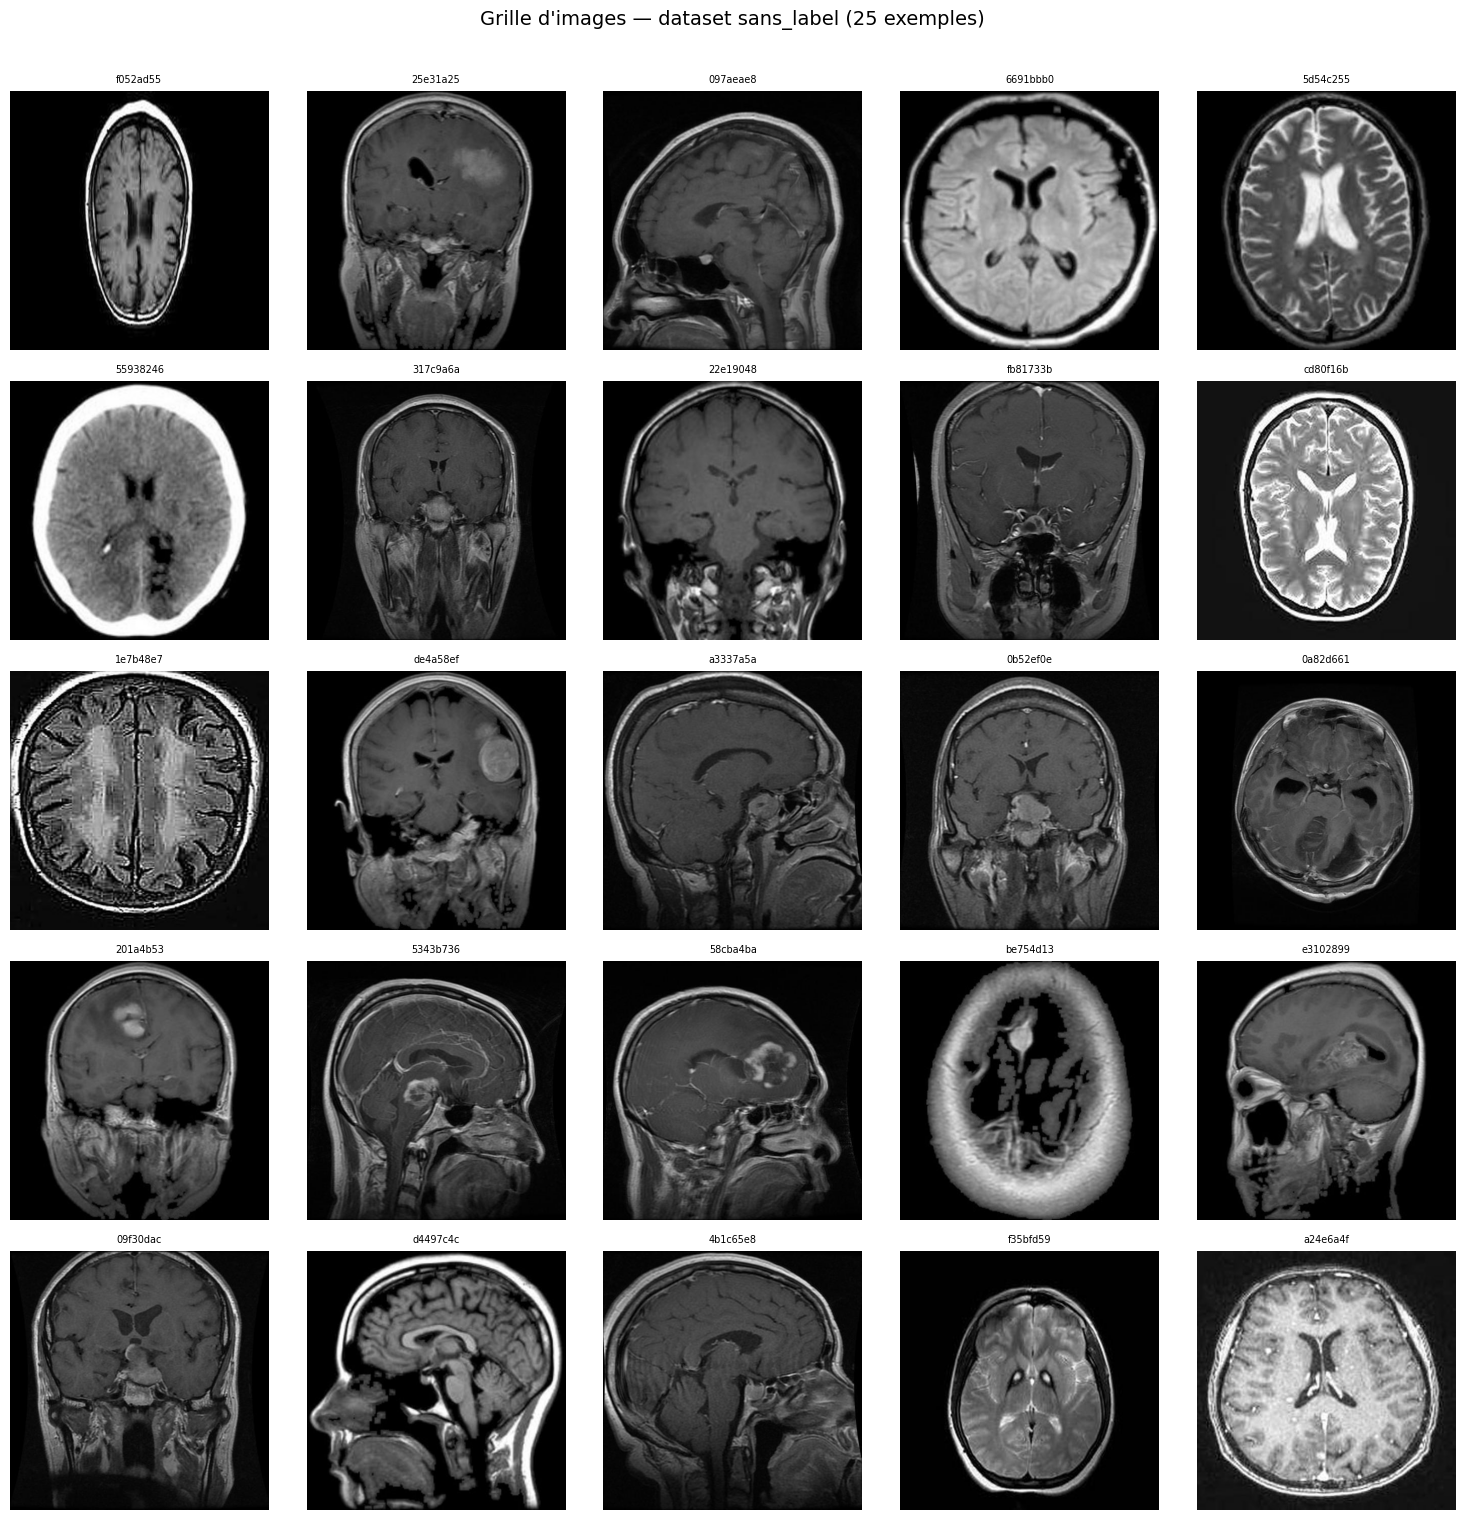

In [4]:
sample_files = random.sample(sans_label_files, SAMPLE_SIZE)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
fig.suptitle("Grille d'images — dataset sans_label (25 exemples)", fontsize=14, y=1.01)

for ax, path in zip(axes.flat, sample_files[:25]):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(path.stem[:8], fontsize=7)

plt.tight_layout()
plt.show()

## 4. Comparaison : cancer vs normal

5 images cancer et 5 images normal côte-à-côte pour observer les différences visuelles.

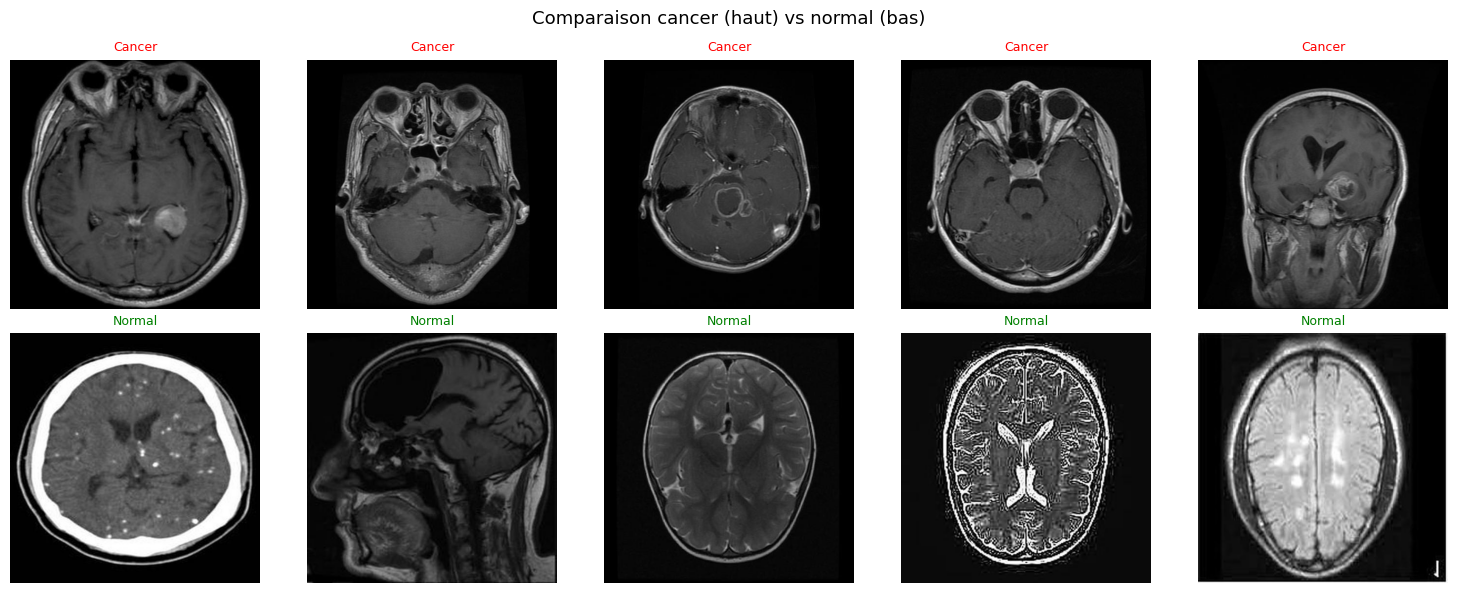

In [5]:
n_show = 5
cancer_sample = random.sample(cancer_files, n_show)
normal_sample = random.sample(normal_files, n_show)

fig, axes = plt.subplots(2, n_show, figsize=(15, 6))
fig.suptitle("Comparaison cancer (haut) vs normal (bas)", fontsize=13)

for i, path in enumerate(cancer_sample):
    axes[0, i].imshow(Image.open(path))
    axes[0, i].axis("off")
    axes[0, i].set_title("Cancer", fontsize=9, color="red")

for i, path in enumerate(normal_sample):
    axes[1, i].imshow(Image.open(path))
    axes[1, i].axis("off")
    axes[1, i].set_title("Normal", fontsize=9, color="green")

plt.tight_layout()
plt.show()

## 5. Distribution des valeurs de pixels

Histogramme des intensités par canal R/G/B sur les 200 images de l'échantillon.

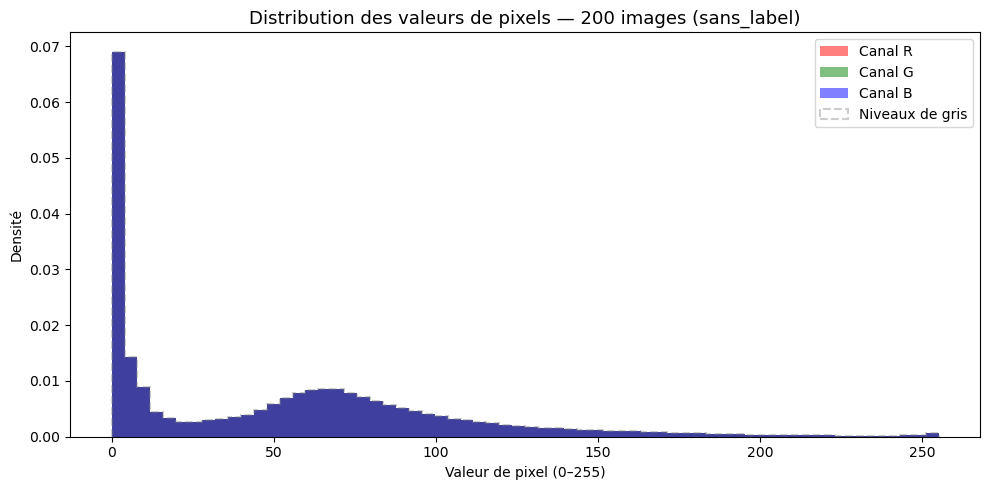

Canal R — moyenne: 52.1, écart-type: 52.3
Canal G — moyenne: 52.1, écart-type: 52.3


Canal B — moyenne: 52.1, écart-type: 52.3
Niveaux de gris — moyenne: 52.1, écart-type: 52.3


In [6]:
channels = {"R": [], "G": [], "B": []}
gray_values = []

for path in sample_files:
    arr = np.array(Image.open(path))
    channels["R"].append(arr[:, :, 0].flatten())
    channels["G"].append(arr[:, :, 1].flatten())
    channels["B"].append(arr[:, :, 2].flatten())
    gray_values.append(np.array(Image.open(path).convert("L")).flatten())

r_all = np.concatenate(channels["R"])
g_all = np.concatenate(channels["G"])
b_all = np.concatenate(channels["B"])
gray_all = np.concatenate(gray_values)

fig, ax = plt.subplots(figsize=(10, 5))
bins = 64
ax.hist(r_all, bins=bins, color="red",   alpha=0.5, density=True, label="Canal R")
ax.hist(g_all, bins=bins, color="green", alpha=0.5, density=True, label="Canal G")
ax.hist(b_all, bins=bins, color="blue",  alpha=0.5, density=True, label="Canal B")
ax.hist(gray_all, bins=bins, color="gray", alpha=0.4, density=True, linestyle="--", histtype="step", label="Niveaux de gris", linewidth=1.5)

ax.set_title(f"Distribution des valeurs de pixels — {SAMPLE_SIZE} images (sans_label)", fontsize=13)
ax.set_xlabel("Valeur de pixel (0–255)")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Canal R — moyenne: {r_all.mean():.1f}, écart-type: {r_all.std():.1f}")
print(f"Canal G — moyenne: {g_all.mean():.1f}, écart-type: {g_all.std():.1f}")
print(f"Canal B — moyenne: {b_all.mean():.1f}, écart-type: {b_all.std():.1f}")
print(f"Niveaux de gris — moyenne: {gray_all.mean():.1f}, écart-type: {gray_all.std():.1f}")

## 6. Observations et conclusions

### Structure du dataset
- **1406 images non étiquetées** + **100 images étiquetées** (50 cancer / 50 normal) = **1506 images au total**
- Seulement **~6.6% des images sont étiquetées** → justifie une approche semi-supervisée
- Les classes sont **parfaitement équilibrées** (50/50) dans les données étiquetées

### Qualité et cohérence
- Toutes les images sont en **RGB 512×512 JPEG** — aucune anomalie détectée
- Le format est homogène et compatible avec les pipelines torchvision standard

### Observations visuelles
- Les images présentent des **variations de contraste et de luminosité** significatives
- Les IRM "cancer" montrent des zones d'intensité anormale (masses, asymétries) visibles à l'œil
- Les IRM "normal" présentent une structure symétrique et homogène

### Points d'attention pour les étapes suivantes
- Les 3 canaux R/G/B ont des distributions similaires → les images sont probablement en **niveaux de gris convertis en RGB** (pseudo-couleur)
- Un **preprocessing de normalisation** (ImageNet ou spécifique domaine médical) sera nécessaire à l'étape 2
- La **grande variabilité intra-classe** des images sans label suggère que le clustering (étape 2) devra utiliser des features profondes (ResNet) plutôt que des features pixel bruts